In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os

# Đường dẫn
DATA_DIR = '../data/'
train = pd.read_csv(os.path.join(DATA_DIR, 'sales.csv'), parse_dates=['Date'])
test = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'), parse_dates=['Date'])
promos = pd.read_csv(os.path.join(DATA_DIR, 'promotions.csv'), parse_dates=['Date'])

# Gộp dữ liệu khuyến mãi
# Giả sử ta lấy giá trị giảm giá trung bình theo ngày
promos_daily = promos.groupby('Date')['discount_value'].sum().reset_index()
train = train.merge(promos_daily, on='Date', how='left').fillna(0)
test = test.merge(promos_daily, on='Date', how='left').fillna(0)

print(f"Dữ liệu sau khi gộp: {train.shape}")

ValueError: Missing column provided to 'parse_dates': 'Date'

In [ ]:
# Đọc thêm file bổ trợ
promos = pd.read_csv(os.path.join(DATA_DIR, 'promotions.csv'), parse_dates=['Date'])
traffic = pd.read_csv(os.path.join(DATA_DIR, 'web_traffic.csv'), parse_dates=['Date'])

# Gộp vào bảng chính (dùng left join để không làm mất ngày nào của file sales)
train = train.merge(promos, on='Date', how='left')
train = train.merge(traffic, on='Date', how='left')

# Xử lý giá trị trống sau khi gộp (ví dụ ngày không có promo thì discount = 0)
train['discount_value'] = train['discount_value'].fillna(0)

ValueError: Missing column provided to 'parse_dates': 'Date'

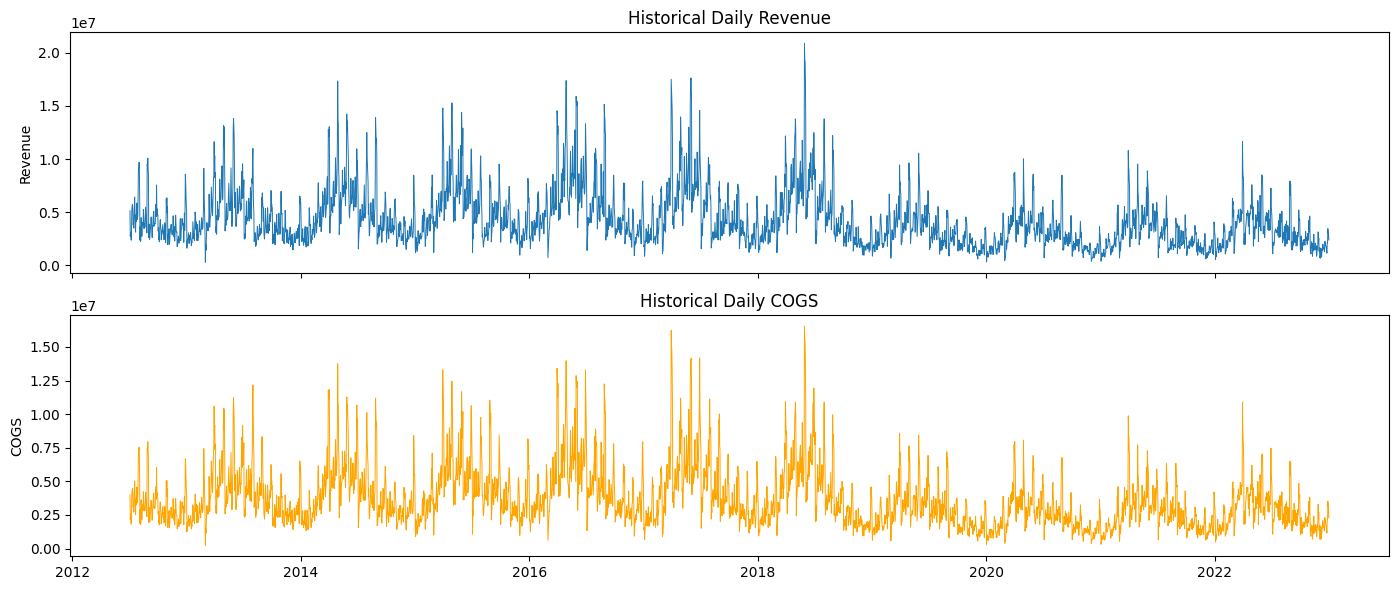

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(train['Date'], train['Revenue'], lw=0.7)
axes[0].set_title('Historical Daily Revenue'); axes[0].set_ylabel('Revenue')
axes[1].plot(train['Date'], train['COGS'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS'); axes[1].set_ylabel('COGS')
plt.tight_layout()
plt.show()

In [ ]:
# Đọc dữ liệu
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
promos = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['Date'])

# BỔ SUNG: Gộp dữ liệu (Merge)
# Gom các khuyến mãi trong ngày lại (nếu 1 ngày có nhiều promo)
promos_daily = promos.groupby('Date').agg({
    'discount_value': 'sum', 
    'promo_type': 'count' # Đếm số lượng chương trình
}).reset_index()
promos_daily.rename(columns={'promo_type': 'promo_count'}, inplace=True)

# Gộp vào tập Train
train = pd.merge(train, promos_daily, on='Date', how='left')

# Điền số 0 cho những ngày không có khuyến mãi
train['discount_value'] = train['discount_value'].fillna(0)
train['promo_count'] = train['promo_count'].fillna(0)

ValueError: Missing column provided to 'parse_dates': 'Date'